# Sensitivity Analysis for SoftwareX Paper

This notebooks performs a sensitivity analysis for the installed capacity and specific CAPEX of both, PV and Stationary Energy Storage in phase *III: Fleet Electrification & Energy System Expansion* of application A ("long-haul") shown in paper's illustrative example section.

In [1]:
%matplotlib inline
import pickle
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd
from matplotlib.lines import Line2D

from lift.backend.scenario import ScenarioResult, SingleScenario
from lift.utils import read_csv

In [2]:
mpl.rcParams.update(
    {
        # Figure
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        # Fonts
        "pgf.texsystem": "pdflatex",
        "text.usetex": True,
        "pgf.rcfonts": False,
        # "text.usetex": True,
        # "font.family": "serif",
        # "font.serif": ["CMU Serif"],
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        # Axes
        "axes.linewidth": 0.8,
        "axes.grid": False,
        # Ticks
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        # Lines
        "lines.linewidth": 1.5,
        "lines.markersize": 5,
        # Legend
        "legend.frameon": False,
        # PDF/PS output
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        # Math
        "mathtext.fontset": "stix",
    }
)

COLORS = {
    "p300c": (0.0, 0.396078431372549, 0.7411764705882353),
    "p158": (0.8901960784313725, 0.4470588235294118, 0.13333333333333333),
    "p383": (0.6352941176470588, 0.6784313725490196, 0.0),
    "p542": (0.39215686274509803, 0.6274509803921569, 0.7843137254901961),
}

LINESTYLES = {
    "solid": "-",
    "dashed": "--",
    "dotted": ":",
    "dashdot": "-.",
    "dashlong": (0, (5, 1)),
}

FILENAME_RESULT = "results_sensitivity_analysis.pkl"  # temporary results
FILENAME_FIGURE = "fig_sensitivity_analysis.pdf"  # results figure
PATH_OUT = Path.cwd() / "out"  # output directory

# select the correct baseline scenario: phase III of application A
SCN_BASELINE = read_csv(Path("case_a.csv"), transpose=True).loc["cost3", :]

### Function Definitions
#### `sensitivity_analysis`
This function accepts a baseline scenario, a single parameter to vary and the corresponding values and returns a dictionary containing the results for the variation's values.

#### `sensitivity_capex_capacity`
This function performs a sensitivity analysis for both specific CAPEX as well as installed capacity of a component.

In [3]:
def sensitivity_analysis(
    baseline: pd.Series,
    parameter: tuple[str, str],
    variation: npt.NDArray,
) -> dict[str, ScenarioResult]:
    rows = []
    for value in variation:
        row = baseline.copy()
        row[parameter] = value
        rows.append(row)

    df_varied = pd.DataFrame(data=rows, index=["_".join((*parameter, str(value))) for value in variation])

    return {scn: SingleScenario.from_series(scn_series).simulate() for scn, scn_series in df_varied.iterrows()}


def sensitivity_capex_capacity(
    baseline: pd.Series,
    block: str,
    variation_capex_spec: npt.NDArray,
    variation_capacities: npt.NDArray,
) -> dict[float, pd.DataFrame]:
    results = {}
    for value in variation_capex_spec:
        scn_baseline_capex = baseline.copy()
        scn_baseline_capex[(block, "capex_spec")] = value
        results_temp = sensitivity_analysis(
            baseline=scn_baseline_capex,
            parameter=(block, "capacity"),
            variation=variation_capacities,
        )

        results[value] = pd.DataFrame.from_dict(
            {
                k: {
                    "totex_dis": v.totex_dis.sum(),
                    "gamma_sc": v.self_consumption,
                    "gamma_ss": v.self_sufficiency,
                    "gamma_ch": v.home_charging_fraction,
                }
                for k, v in results_temp.items()
            },
            orient="index",
        )

    return results

### Sensitivity Analysis
Perform a sensitivity analysis for the parameters `capex_spec` and `capacity` for the blocks `PV` and `ESS`.
Besides the total discounted costs the occuring self consumption rate $\gamma_{sc}$, the self sufficiency rate $\gamma_{ss}$ as well as the home charging rate $\gamma_{ch}$ are evaluated.

`PV`
- `capacity`: $0 – 2000 kW_p$
- `capex_spec`: $700 - 1100 €/kW_p$

`ESS`
- `capacity`: $0 – 800 kWh$
- `capex_spec`: $350 - 550 €/kWh$



In [4]:
variation_capex_spec_pv = np.linspace(0.7, 1.1, 5)
variation_capacities_pv = np.linspace(0, 2000e3, 41)

variation_capex_spec_ess = np.linspace(0.35, 0.55, 5)
variation_capacities_ess = np.linspace(0, 800e3, 33)

# Try to load results from results file
if (PATH_OUT / FILENAME_RESULT).is_file():
    with open(PATH_OUT / FILENAME_RESULT, "rb") as f:
        data = pickle.load(f)
    results_pv = data["pv"]
    results_ess = data["ess"]

else:
    # Perform sensitivity analysis for PV and ESS
    results_pv = sensitivity_capex_capacity(
        baseline=SCN_BASELINE,
        block="pv",
        variation_capex_spec=variation_capex_spec_pv,
        variation_capacities=variation_capacities_pv,
    )

    results_ess = sensitivity_capex_capacity(
        baseline=SCN_BASELINE,
        block="ess",
        variation_capex_spec=variation_capex_spec_ess,
        variation_capacities=variation_capacities_ess,
    )

    # Save results to file
    with open(PATH_OUT / FILENAME_RESULT, "wb") as f:
        pickle.dump({"pv": results_pv, "ess": results_ess}, f)

### Plotting
Plot the results in a figure containing two vertically stacked subplots. One for PV and one for ESS. Save the plot to the output directory.

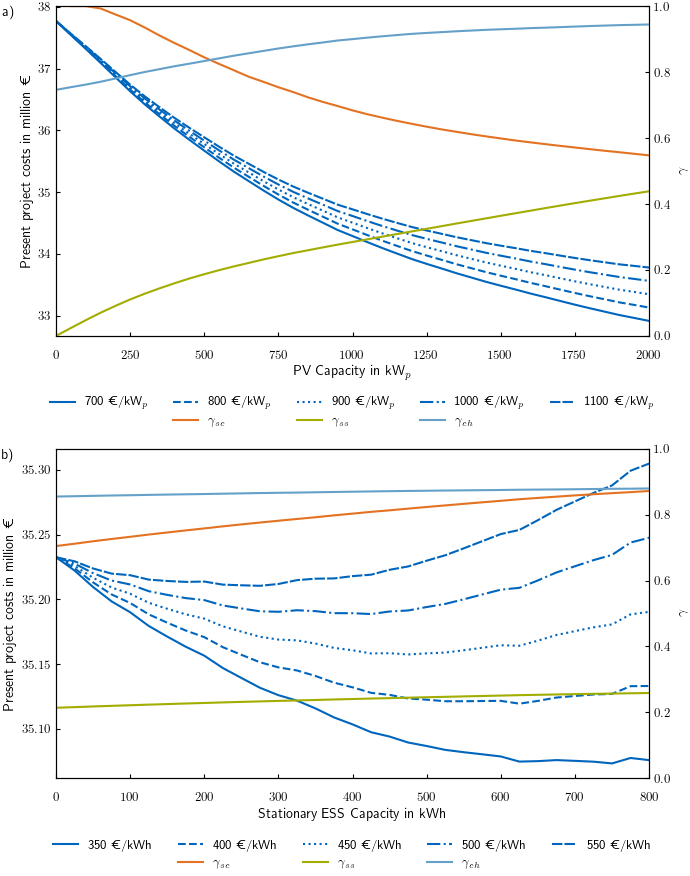

In [5]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(7.14, 9))


def add_plot(
    ax: plt.Axes,
    subplot_id: str,
    x: npt.NDArray,
    results: dict[float, pd.DataFrame],
    xunit: str,
    xlabel: str,
):
    # plot cost results of all capex_spec variations
    for i, (capex_spec, result) in enumerate(results.items()):
        ax.plot(
            x,
            result["totex_dis"] / 1e6,
            label=f"{capex_spec * 1e3:.0f} {xunit}",
            color=COLORS["p300c"],
            linestyle=list(LINESTYLES.values())[i],
        )

    # technical KPIs do not depend on capex_spec -> select the first result object
    result_repr = next(iter(results.values()))

    # plot technical KPIs on secondary y axis on the right
    ax_twin = ax.twinx()
    ax_twin.plot(x, result_repr["gamma_sc"], label=r"$\gamma_{sc}$", color=COLORS["p158"])
    ax_twin.plot(x, result_repr["gamma_ss"], label=r"$\gamma_{ss}$", color=COLORS["p383"])
    ax_twin.plot(x, result_repr["gamma_ch"], label=r"$\gamma_{ch}$", color=COLORS["p542"])

    # Set x and y axies properties
    ax.set_xlabel(xlabel)
    ax.set_xlim(min(x), max(x))
    ax.tick_params(axis="x", pad=10)
    ax.set_ylabel("Present project costs in million €")
    ax_twin.set_ylabel(r"$\gamma$")
    ax_twin.set_ylim(0.0, 1.0)

    # combine legend handles and labels to get 5 column layout with
    #  - capex in top row
    #  - technical KPIs centered in bottom row
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax_twin.get_legend_handles_labels()
    dummy_handle = Line2D([], [], alpha=0)

    handles = [x for pair in zip(lines_1, [dummy_handle, *lines_2, dummy_handle]) for x in pair]
    labels = [x for pair in zip(labels_1, ["", *labels_2, ""]) for x in pair]

    # create legend below plotting area
    ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=False)

    # add subplot ID to top left corner of subplot
    ax.text(-0.07, 1, subplot_id, transform=ax.transAxes, va="top", ha="right")


add_plot(
    ax=ax1,
    subplot_id="a)",
    x=variation_capacities_pv * 1e-3,
    results=results_pv,
    xunit=r"€/kW$_p$",
    xlabel=r"PV Capacity in kW$_p$",
)
add_plot(
    ax=ax2,
    subplot_id="b)",
    x=variation_capacities_ess * 1e-3,
    results=results_ess,
    xunit=r"€/kWh",
    xlabel="Stationary ESS Capacity in kWh",
)

plt.tight_layout()
plt.savefig(PATH_OUT / FILENAME_FIGURE)
plt.show()